# Pythia: Momentum Investing — Strategy Builder & Backtester

This notebook builds a full quantitative momentum investing pipeline on the S&P 500
universe.



# Notebook Structure

| Section | Topic |
|---------|-------|
| **1** | Imports & Global Configuration |
| **2** | Incremental Data Update |
| **3** | Data Quality & Cleaning |
| **4** | Exploratory Data Analysis |
| **5** | Momentum Signal Definitions |
| **6** | Walk-Forward Backtesting Engine |
| **7** | Machine Learning Layer |
| **8** | Performance Metrics & Visualisation |
| **9** | Fama-French 3-Factor Risk Adjustment |
| **10** | Current Stock Screener |



> **Data source:** 10-year daily OHLCV prices for S&P 500 constituents stored in
> `sp500_prices.duckdb` (table: `daily_prices`). Built with `download_sp500_to_duckdb.py`
> and kept current by Section 2 of this notebook.

---
## 1. Imports & Global Configuration

All imports in a single cell so dependencies are explicit and easy to audit.
All numeric constants are defined here — never buried inside functions — so
changing any assumption (cost, lookback, threshold) requires editing one place only.

| Library | Purpose |
|---------|---------|
| `duckdb` | Analytical SQL engine — reads the local price database |
| `numpy` | Fast numerical arrays and mathematical operations |
| `pandas` | DataFrames, time-series resampling, method-chaining |
| `yfinance` | Fetches missing price history from Yahoo Finance |
| `matplotlib / seaborn` | Static charts and dashboards |
| `scipy.stats` | Normal distribution — used in signal z-scoring |
| `sklearn` | Logistic Regression, Random Forest, walk-forward split |
| `lightgbm` | Gradient boosting classifier — strongest ML baseline |
| `requests` | Fetches Fama-French factor CSV from Kenneth French's website |

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import time
import warnings
import requests
from io import StringIO
from datetime import date, timedelta
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Data & numerics ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import duckdb
import yfinance as yf

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Statistics & machine learning ─────────────────────────────────────────────
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

# ── Seaborn global theme ──────────────────────────────────────────────────────
# 'whitegrid' gives clean axes; font_scale=1.1 makes text readable in notebooks
sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.1)

# ── Display options ───────────────────────────────────────────────────────────
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL CONFIGURATION
# Edit this cell to change any assumption project-wide.
# ─────────────────────────────────────────────────────────────────────────────

# ── Paths ─────────────────────────────────────────────────────────────────────
DB_PATH = Path("sp500_prices.duckdb")

# ── Finance constants ─────────────────────────────────────────────────────────
TRADING_DAYS          = 252      # exchange-open days per calendar year
RF_ANNUAL             = 0.04     # annual risk-free rate (4 %)
BACKTEST_START        = "2015-01-01"   # backtest window start date

# ── Backtest parameters ───────────────────────────────────────────────────────
TRANSACTION_COST_BPS  = 10       # flat cost per side in basis points (1 bp = 0.01 %)
TOP_DECILE            = 0.10     # top 10 % of ranked stocks → long portfolio
BOTTOM_DECILE         = 0.10     # bottom 10 % of ranked stocks → short portfolio
REBALANCE_FREQ        = "ME"     # pandas month-end offset alias

# ── Data quality thresholds ───────────────────────────────────────────────────
MIN_HISTORY_YEARS     = 8        # tickers with fewer years of data are excluded
MAX_CONSEC_MISSING    = 5        # flag tickers with gaps longer than 5 trading days
MAX_DAILY_RETURN      = 0.40     # flag single-day moves above 40 % (likely data errors)

# ── Colour palette ────────────────────────────────────────────────────────────
# Consistent colours used across every chart — defined as a dict so the
# mapping is always explicit, never index-dependent.
COLOURS = {
    "MOM_12_1"   : "#2196F3",   # blue
    "MOM_3_1"    : "#4CAF50",   # green
    "MA_Cross"   : "#FF9800",   # orange
    "RSI_14"     : "#9C27B0",   # purple
    "Composite"  : "#F44336",   # red
    "ML"         : "#00BCD4",   # cyan
    "Benchmark"  : "#9E9E9E",   # grey
}

SIGNAL_COLS = ["MOM_12_1", "MOM_3_1", "MA_Cross", "RSI_14"]   # raw signals (no Composite)

print("✓ Libraries loaded and configuration set.")
print(f"  DB path          : {DB_PATH}")
print(f"  Backtest start   : {BACKTEST_START}")
print(f"  Transaction cost : {TRANSACTION_COST_BPS} bps per side")
print(f"  Rebalance freq   : {REBALANCE_FREQ}")

✓ Libraries loaded and configuration set.
  DB path          : sp500_prices.duckdb
  Backtest start   : 2015-01-01
  Transaction cost : 10 bps per side
  Rebalance freq   : ME


---
## 2. Incremental Data Update

### Why incremental?

The original `download_sp500_to_duckdb.py` script built the database by pulling
10 years of history for ~500 tickers — a process requiring anti-blocking safeguards
and 10–15 minutes to run. Each time **this notebook** is run, we only need to fetch
the days that are missing since the last download — typically a handful of trading
days. This is fast (seconds) and quiet enough that no rate-limiting safeguards are needed.

### Logic

For each ticker already in `daily_prices`:

1. Query `MAX(date)` — the last date stored for that ticker
2. If `MAX(date) < yesterday`, download only the missing window from yfinance
3. Append new rows using `INSERT OR IGNORE` — safe to re-run, no duplicates
4. A 0.3-second pause between tickers is sufficient at this request volume

The ticker list comes directly from DuckDB — no external lookup required.

In [2]:
# ── Helper: get the last stored date per ticker ───────────────────────────────
def get_last_dates(con):
    """
    Returns a DataFrame [ticker, last_date] — the most recent row in
    daily_prices for every ticker.  Used to determine which tickers are stale.
    """
    return con.execute("""
        SELECT ticker, MAX(date) AS last_date
        FROM   daily_prices
        GROUP  BY ticker
        ORDER  BY ticker
    """).df()


# ── Helper: fetch missing days from yfinance for one ticker ───────────────────
def fetch_missing(ticker, from_date, to_date):
    """
    Downloads OHLCV for [from_date, to_date] for a single ticker.
    Returns a tidy DataFrame ready for INSERT, or None if yfinance
    returned an empty result (delisted / no trading days in window).

    auto_adjust=True gives split- and dividend-adjusted prices — matching
    the schema the database was built with.
    """
    raw = yf.download(
        tickers=ticker,
        start=from_date.strftime("%Y-%m-%d"),
        end=(to_date + timedelta(days=1)).strftime("%Y-%m-%d"),  # yfinance end is exclusive
        auto_adjust=True,
        progress=False,
        threads=False,
    )

    if raw is None or raw.empty:
        return None

    # yfinance returns MultiIndex columns even for a single ticker — flatten them
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    df = raw.reset_index()
    df.columns = [c.lower().strip() for c in df.columns]

    # Normalise the date column name (varies slightly across yfinance versions)
    date_col = [c for c in df.columns if "date" in c or "datetime" in c][0]
    df = df.rename(columns={date_col: "date"})

    # Keep only columns that exist in daily_prices
    keep = [c for c in ["date", "open", "high", "low", "close", "volume"] if c in df.columns]
    df = df[keep].copy()

    df["date"]   = pd.to_datetime(df["date"]).dt.date
    df["ticker"] = ticker
    for col in ["open", "high", "low", "close"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if "volume" in df.columns:
        df["volume"] = pd.to_numeric(df["volume"], errors="coerce").astype("Int64")

    df = df.dropna(subset=["close"])
    return df if not df.empty else None


# ── Helper: insert new rows safely ───────────────────────────────────────────
def insert_rows(con, df):
    """
    Inserts df into daily_prices using INSERT OR IGNORE.
    The PRIMARY KEY on (date, ticker) prevents duplicates, so this
    function is safe to call multiple times on the same data.
    """
    if df is None or df.empty:
        return 0
    con.register("_tmp", df)
    con.execute("""
        INSERT OR IGNORE INTO daily_prices
        SELECT date, ticker, open, high, low, close, volume
        FROM   _tmp
    """)
    con.unregister("_tmp")
    return len(df)


print("✓ Update helper functions defined.")

✓ Update helper functions defined.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# RUN INCREMENTAL UPDATE
# ─────────────────────────────────────────────────────────────────────────────
PAUSE   = 0.3          # seconds between tickers — sufficient at this volume
TODAY   = date.today()
YEST    = TODAY - timedelta(days=1)

con           = duckdb.connect(str(DB_PATH))
last_dates_df = get_last_dates(con)

# ── Identify stale tickers (last_date < yesterday) ────────────────────────────
stale = (
    last_dates_df
    .assign(last_date=lambda x: pd.to_datetime(x["last_date"]).dt.date)
    .query("last_date < @YEST")
    .reset_index(drop=True)
)

print(f"Tickers in database    : {len(last_dates_df):>5}")
print(f"Already up-to-date     : {len(last_dates_df) - len(stale):>5}")
print(f"Tickers to update      : {len(stale):>5}")
print(f"Fetching up to         : {YEST}\n")

# ── Update loop ───────────────────────────────────────────────────────────────
total_rows     = 0
updated        = []
failed         = []

for _, row in stale.iterrows():
    ticker     = row["ticker"]
    fetch_from = row["last_date"] + timedelta(days=1)

    if fetch_from > YEST:     # weekend edge-case: nothing to fetch
        continue

    new_data = fetch_missing(ticker, fetch_from, YEST)

    if new_data is None:
        failed.append(ticker)
    else:
        n = insert_rows(con, new_data)
        total_rows += n
        updated.append({"Ticker": ticker, "New Rows": n,
                         "From": fetch_from, "To": new_data["date"].max()})

    time.sleep(PAUSE)

# ── Final DB stats ────────────────────────────────────────────────────────────
stats_row = con.execute("""
    SELECT MIN(date) AS earliest, MAX(date) AS latest,
           COUNT(DISTINCT ticker) AS n_tickers
    FROM   daily_prices
""").df()

con.close()

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 50)
print("  UPDATE COMPLETE")
print("=" * 50)
print(f"  Tickers updated      : {len(updated):>5}")
print(f"  New rows inserted    : {total_rows:>5,}")
print(f"  Tickers with no data : {len(failed):>5}")
print(f"  DB earliest date     : {stats_row['earliest'].iloc[0]}")
print(f"  DB latest date       : {stats_row['latest'].iloc[0]}")
print(f"  Total tickers in DB  : {stats_row['n_tickers'].iloc[0]:>5}")
print("=" * 50)

if failed:
    print(f"\n⚠  Tickers returning no data (possibly delisted):")
    print("   " + ", ".join(failed))

if updated:
    display(
        pd.DataFrame(updated)
        .sort_values("New Rows", ascending=False)
        .head(20)
        .reset_index(drop=True)
        .style
        .format({"New Rows": "{:,}"})
        .set_caption("Tickers updated this run (top 20 by rows added)")
        .hide(axis="index")
    )
else:
    print("\n✓ Database already current — no new rows needed.")

Tickers in database    :   503
Already up-to-date     :     0
Tickers to update      :   503
Fetching up to         : 2026-03-20

  UPDATE COMPLETE
  Tickers updated      :   503
  New rows inserted    : 1,006
  Tickers with no data :     0
  DB earliest date     : 2016-03-21 00:00:00
  DB latest date       : 2026-03-20 00:00:00
  Total tickers in DB  :   503


Ticker,New Rows,From,To
A,2,2026-03-19,2026-03-20
NFLX,2,2026-03-19,2026-03-20
NWSA,2,2026-03-19,2026-03-20
NWS,2,2026-03-19,2026-03-20
NVR,2,2026-03-19,2026-03-20
NVDA,2,2026-03-19,2026-03-20
NUE,2,2026-03-19,2026-03-20
NTRS,2,2026-03-19,2026-03-20
NTAP,2,2026-03-19,2026-03-20
NSC,2,2026-03-19,2026-03-20


---
## 3. Data Quality & Cleaning

Before building signals or running a backtest we need to verify that the raw
data is fit for purpose. Three checks are applied — each one addresses a
distinct failure mode:

| Check | Threshold | Why it matters |
|-------|-----------|----------------|
| **Insufficient history** | < 8 years of trading days | Momentum signals need at least 12 months of history; 8 years ensures we can also run the full 2015–present backtest |
| **Large consecutive gaps** | > 5 missing trading days | Gaps longer than a working week suggest a data feed problem, not just a public holiday |
| **Abnormal single-day returns** | \|return\| > 40 % | Moves this large are almost always split or dividend data errors rather than real price moves |

Tickers that fail any check are removed from the **clean universe** and recorded
in `flagged_df` with the reason, so we have a full audit trail.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# LOAD FULL PRICE TABLE FROM DUCKDB
# ─────────────────────────────────────────────────────────────────────────────
con      = duckdb.connect(str(DB_PATH))
prices_raw = con.execute("""
    SELECT date, ticker, close
    FROM   daily_prices
    ORDER  BY ticker, date
""").df()
con.close()

prices_raw["date"] = pd.to_datetime(prices_raw["date"])

print(f"Raw table shape : {prices_raw.shape}")
print(f"Tickers         : {prices_raw['ticker'].nunique()}")
print(f"Date range      : {prices_raw['date'].min().date()}  →  {prices_raw['date'].max().date()}")

Raw table shape : (1230611, 3)
Tickers         : 503
Date range      : 2016-03-21  →  2026-03-20


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# QUALITY CHECKS
# ─────────────────────────────────────────────────────────────────────────────
MIN_TRADING_DAYS = int(MIN_HISTORY_YEARS * TRADING_DAYS)

flagged = {}    # {ticker: reason}  — audit trail of removed tickers

# ── Check 1: Insufficient history ────────────────────────────────────────────
# Count how many rows each ticker has; flag those below the minimum.
ticker_counts = prices_raw.groupby("ticker")["date"].count()
short_history = ticker_counts[ticker_counts < MIN_TRADING_DAYS].index.tolist()
for t in short_history:
    flagged[t] = "insufficient history"

print(f"Check 1 — Insufficient history (< {MIN_TRADING_DAYS} days) : {len(short_history)} tickers")

# ── Check 2: Large consecutive gaps ──────────────────────────────────────────
# For each ticker, compute the number of calendar days between consecutive rows.
# A gap of > 7 calendar days (≈ 5 trading days + weekend) flags a data problem.
prices_sorted = prices_raw.sort_values(["ticker", "date"])
prices_sorted["gap"] = (
    prices_sorted
    .groupby("ticker")["date"]
    .diff()
    .dt.days
)
max_gap = prices_sorted.groupby("ticker")["gap"].max()
large_gaps = max_gap[max_gap > 7].index.tolist()
for t in large_gaps:
    if t not in flagged:
        flagged[t] = "large consecutive gap"

print(f"Check 2 — Large consecutive gaps (> 7 calendar days) : {len(large_gaps)} tickers")

# ── Check 3: Abnormal single-day returns ──────────────────────────────────────
# Compute daily log-returns per ticker; flag any with |return| > 40 %.
# This almost always indicates a data error (split not adjusted, bad feed, etc.)
prices_sorted["log_ret"] = (
    prices_sorted
    .groupby("ticker")["close"]
    .transform(lambda x: np.log(x / x.shift(1)))
)
max_abs_ret = prices_sorted.groupby("ticker")["log_ret"].apply(lambda x: x.abs().max())
bad_returns = max_abs_ret[max_abs_ret > MAX_DAILY_RETURN].index.tolist()
for t in bad_returns:
    if t not in flagged:
        flagged[t] = "abnormal single-day return"

print(f"Check 3 — Abnormal single-day returns (> {MAX_DAILY_RETURN:.0%}) : {len(bad_returns)} tickers")

# ── Build clean universe and flagged table ────────────────────────────────────
flagged_df = (
    pd.DataFrame(flagged.items(), columns=["Ticker", "Reason"])
    .sort_values("Reason")
    .reset_index(drop=True)
)

clean_tickers = [t for t in prices_raw["ticker"].unique() if t not in flagged]
universe_df   = prices_raw[prices_raw["ticker"].isin(clean_tickers)].copy()

print(f"\n{'='*45}")
print(f"  Tickers flagged & removed : {len(flagged):>4}")
print(f"  Clean universe size       : {len(clean_tickers):>4}")
print(f"{'='*45}")

if not flagged_df.empty:
    display(
        flagged_df
        .style
        .set_caption("Flagged tickers — removed from clean universe")
        .hide(axis="index")
    )

Check 1 — Insufficient history (< 2016 days) : 25 tickers
Check 2 — Large consecutive gaps (> 7 calendar days) : 0 tickers
Check 3 — Abnormal single-day returns (> 40%) : 28 tickers

  Tickers flagged & removed :   52
  Clean universe size       :  451


Ticker,Reason
ALGN,abnormal single-day return
CCL,abnormal single-day return
CNC,abnormal single-day return
CVNA,abnormal single-day return
DHR,abnormal single-day return
DVN,abnormal single-day return
DXCM,abnormal single-day return
EPAM,abnormal single-day return
FANG,abnormal single-day return
FISV,abnormal single-day return


---
## 4. Exploratory Data Analysis

Before building signals we inspect the clean universe along three dimensions:

1. **Monthly return distribution** — what does the cross-sectional return distribution
   look like? How far does it deviate from normality? This sets expectations for the
   signal distributions we will build in Section 5.

2. **Rolling universe size** — how many clean tickers have data in each month?
   A shrinking universe in the early years is normal (the database starts in 2015);
   a sudden drop later would indicate a data problem.

3. **Annualised volatility distribution** — how spread out is the risk profile
   across the universe? This matters for interpreting signal strength — a stock
   with a high momentum score but extreme volatility carries much more uncertainty
   than a stock with the same score and low volatility.

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE MONTHLY RETURNS FOR THE CLEAN UNIVERSE
# ─────────────────────────────────────────────────────────────────────────────
# Resample daily close prices to month-end, then compute log-returns.
# Log-returns are time-additive and approximately normally distributed —
# the standard input for cross-sectional momentum analysis.

monthly_prices = (
    universe_df
    .set_index("date")
    .groupby("ticker")["close"]
    .resample(REBALANCE_FREQ)
    .last()                          # take the last trading day of each month
    .reset_index()
    .rename(columns={"date": "month_end"})
    .sort_values(["ticker", "month_end"])
    .assign(
        log_ret=lambda x: (
            x.groupby("ticker")["close"]
             .transform(lambda p: np.log(p / p.shift(1)))
        )
    )
    .dropna(subset=["log_ret"])
)

# Pivot to wide format: rows = months, columns = tickers
# This is the primary data structure used throughout Sections 5–9.
monthly_ret_wide = (
    monthly_prices
    .pivot(index="month_end", columns="ticker", values="log_ret")
)

print(f"Monthly return matrix : {monthly_ret_wide.shape[0]} months × {monthly_ret_wide.shape[1]} tickers")
print(f"Date range            : {monthly_ret_wide.index.min().date()}  →  {monthly_ret_wide.index.max().date()}")

Monthly return matrix : 120 months × 451 tickers
Date range            : 2016-04-30  →  2026-03-31


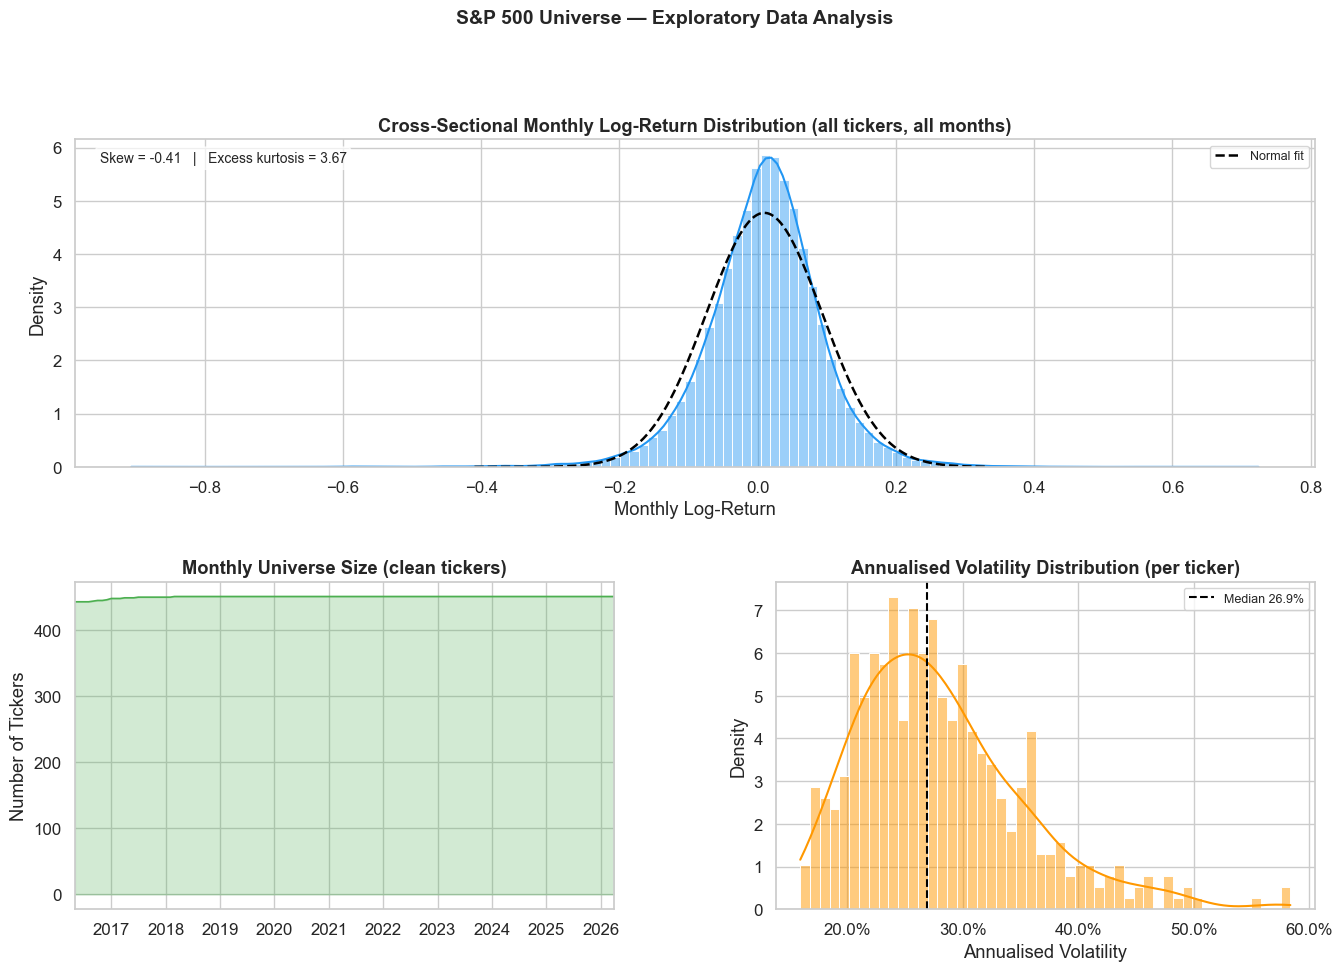


Cross-sectional return stats:
  Mean monthly return  : 0.0095  (11.45% annualised)
  Std monthly return   : 0.0836  (28.95% annualised)
  Median ann. vol      : 26.87%


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA DASHBOARD — 3-panel figure
# ─────────────────────────────────────────────────────────────────────────────
# GridSpec gives fine control over subplot sizes.
# Row 0 : monthly return distribution (full width — most information)
# Row 1 : rolling universe size (left) | volatility distribution (right)

fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

ax0 = fig.add_subplot(gs[0, :])    # full top row
ax1 = fig.add_subplot(gs[1, 0])    # bottom left
ax2 = fig.add_subplot(gs[1, 1])    # bottom right

# ── Panel 1: Cross-sectional monthly return distribution ─────────────────────
# Stack all returns into one long series for the histogram.
# Overlay a fitted normal to show how much the tails deviate.
all_returns = monthly_ret_wide.stack().dropna()
mu, sigma   = all_returns.mean(), all_returns.std()

sns.histplot(all_returns, bins=120, kde=True, stat="density",
             color="#2196F3", alpha=0.45, ax=ax0)

# Fitted normal curve
x_range = np.linspace(all_returns.quantile(0.001), all_returns.quantile(0.999), 400)
ax0.plot(x_range, stats.norm.pdf(x_range, mu, sigma),
         "k--", lw=1.8, label="Normal fit")

skew_val = float(all_returns.skew())
kurt_val = float(all_returns.kurt())
ax0.text(0.02, 0.93,
         f"Skew = {skew_val:.2f}   |   Excess kurtosis = {kurt_val:.2f}",
         transform=ax0.transAxes, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

ax0.set_title("Cross-Sectional Monthly Log-Return Distribution (all tickers, all months)",
              fontweight="bold")
ax0.set_xlabel("Monthly Log-Return")
ax0.legend(fontsize=9)

# ── Panel 2: Rolling universe size (quality-filtered) ─────────────────────────
# Count how many tickers have a non-NaN return in each month.
universe_size = monthly_ret_wide.notna().sum(axis=1)

ax1.fill_between(universe_size.index, universe_size.values,
                 alpha=0.25, color="#4CAF50")
ax1.plot(universe_size.index, universe_size.values,
         color="#4CAF50", lw=1.2)
ax1.set_title("Monthly Universe Size (clean tickers)", fontweight="bold")
ax1.set_ylabel("Number of Tickers")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.margins(x=0)

# ── Panel 3: Annualised volatility distribution ────────────────────────────────
# Per-ticker annualised volatility over the full history.
# Scaling: daily std × √252 ≡ monthly std × √12.
ann_vol = (
    monthly_ret_wide
    .std()
    .mul(np.sqrt(12))          # annualise from monthly std
    .dropna()
    .rename("ann_vol")
)

sns.histplot(ann_vol, bins=50, kde=True, stat="density",
             color="#FF9800", alpha=0.5, ax=ax2)
ax2.axvline(ann_vol.median(), color="black", lw=1.5, ls="--",
            label=f"Median {ann_vol.median():.1%}")
ax2.set_title("Annualised Volatility Distribution (per ticker)", fontweight="bold")
ax2.set_xlabel("Annualised Volatility")
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(fontsize=9)

plt.suptitle("S&P 500 Universe — Exploratory Data Analysis",
             fontsize=14, fontweight="bold", y=1.01)
plt.show()

print(f"\nCross-sectional return stats:")
print(f"  Mean monthly return  : {mu:.4f}  ({mu*12:.2%} annualised)")
print(f"  Std monthly return   : {sigma:.4f}  ({sigma*np.sqrt(12):.2%} annualised)")
print(f"  Median ann. vol      : {ann_vol.median():.2%}")

---
## 5. Momentum Signal Definitions

We construct four momentum signals — two price-return based (computed on monthly prices)
and two technical-indicator based (computed on daily prices then sampled monthly).
Each signal is a standalone function that returns a DataFrame of the same shape
as `monthly_ret_wide`: rows = month-end dates, columns = tickers.

### Signal overview

| Signal | Frequency | Definition |
|--------|-----------|------------|
| **MOM_12_1** | Monthly | Log return from month t−12 to t−1 (skip most recent month) |
| **MOM_3_1** | Monthly | Log return from month t−3 to t−1 (skip most recent month) |
| **MA_Cross** | Daily → monthly | EMA₅₀ / EMA₂₀₀ − 1, sampled at month-end |
| **RSI_14** | Daily → monthly | 14-day RSI sampled at month-end |
| **Composite** | Monthly | Equal-weighted z-score average of all four signals |

### Why skip the most recent month in MOM_12_1 and MOM_3_1?

Jegadeesh & Titman (1993) — the foundational momentum paper — showed that the
most recent month's return actually **reverses** in the following month (short-term
mean reversion). By skipping month t to t−1, we isolate the medium-term trend
from this short-term noise. This is standard practice in academic and practitioner
momentum research.

### Why a continuous signal instead of binary crossover for MA_Cross?

A binary signal (EMA₅₀ > EMA₂₀₀ = 1, else 0) discards information — a stock
barely above the crossover and one far above it would get the same score.
The **ratio minus 1** preserves the magnitude: a value of +0.05 means the fast MA
is 5% above the slow MA, while +0.20 means it is much further ahead. This makes
the signal rankable across stocks, which is what the backtesting engine needs.

In [26]:
# ── Monthly price pivot (month-end close, wide format) ─────────────────────────
# This is used by MOM_12_1 and MOM_3_1.  We already have monthly_prices from
# Section 4, so we just pivot to wide format indexed by month-end.
monthly_close_wide = (
    monthly_prices
    .pivot(index="month_end", columns="ticker", values="close")
)


# ─────────────────────────────────────────────────────────────────────────────
# SIGNAL FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def compute_mom_12_1(monthly_close):
    """
    Classic 12-1 month momentum (Jegadeesh & Titman, 1993).
    Return from month t-12 to t-1, skipping the most recent month.

    Formula: log(P_{t-1} / P_{t-12})
    The .shift(1) skips the most recent month; .shift(12) goes back one year.
    """
    return np.log(monthly_close.shift(1) / monthly_close.shift(12))


def compute_mom_3_1(monthly_close):
    """
    Short-term 3-1 month momentum.
    Same skip-one-month convention as MOM_12_1 but over a shorter horizon.

    Formula: log(P_{t-1} / P_{t-3})
    """
    return np.log(monthly_close.shift(1) / monthly_close.shift(3))


def compute_ma_cross(daily_prices_df, tickers):
    """
    Moving-average crossover: EMA_50 / EMA_200 - 1, sampled at month-end.

    A positive value means the fast (50-day) EMA is above the slow (200-day) EMA,
    indicating an uptrend.  The magnitude tells us how far apart they are —
    more informative than a binary above/below flag.

    Computed on daily prices then resampled to month-end so the EMA calculations
    use the full daily resolution they require.
    """
    results = {}
    for ticker in tickers:
        px = (
            daily_prices_df
            .query("ticker == @ticker")
            .set_index("date")["close"]
            .sort_index()
        )
        ema50  = px.ewm(span=50,  adjust=False).mean()
        ema200 = px.ewm(span=200, adjust=False).mean()
        ratio  = (ema50 / ema200) - 1
        # Sample at month-end to match the other signal DataFrames
        results[ticker] = ratio.resample(REBALANCE_FREQ).last()

    return pd.DataFrame(results)


def compute_rsi(daily_prices_df, tickers, period=14):
    """
    Relative Strength Index (RSI) with a 14-day lookback, sampled at month-end.

    RSI measures the speed and magnitude of recent price moves:
      - Values near 70+ indicate strong recent gains (strong momentum)
      - Values near 30- indicate recent weakness

    We use it as a continuous momentum signal: higher RSI = stronger momentum.
    Wilder's original exponential smoothing method is used (adjust=False).
    """
    results = {}
    for ticker in tickers:
        px = (
            daily_prices_df
            .query("ticker == @ticker")
            .set_index("date")["close"]
            .sort_index()
        )
        delta = px.diff()
        gain  = delta.clip(lower=0)
        loss  = (-delta).clip(lower=0)
        # Wilder's smoothing: EMA with span = 2*period - 1
        avg_gain = gain.ewm(span=2*period - 1, adjust=False).mean()
        avg_loss = loss.ewm(span=2*period - 1, adjust=False).mean()
        rs  = avg_gain / avg_loss.replace(0, np.nan)
        rsi = 100 - (100 / (1 + rs))
        results[ticker] = rsi.resample(REBALANCE_FREQ).last()

    return pd.DataFrame(results)


def z_score_cross_section(signal_df):
    """
    Normalise each signal to have zero mean and unit standard deviation
    across the cross-section (all tickers) in each month.

    This makes signals from different scales directly comparable and
    ensures no single signal dominates the Composite due to scale alone.
    """
    return signal_df.apply(lambda row: (row - row.mean()) / row.std(), axis=1)


def compute_composite(signal_dict):
    """
    Equal-weighted average of the z-scored individual signals.

    Each signal is first z-scored cross-sectionally (so all signals are on
    the same scale), then averaged.  A stock with a high composite score
    is ranked highly by multiple independent signals simultaneously —
    a more robust buy candidate than one ranked highly by a single signal.
    """
    z_signals = {name: z_score_cross_section(df) for name, df in signal_dict.items()}
    # Stack all z-scored DataFrames and take the mean across signals
    return pd.concat(z_signals.values()).groupby(level=0).mean()


print("✓ Signal functions defined.")

✓ Signal functions defined.


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE ALL SIGNALS
# ─────────────────────────────────────────────────────────────────────────────
# Load daily prices for the clean universe (needed for MA_Cross and RSI_14).
con = duckdb.connect(str(DB_PATH))
daily_clean = con.execute("""
    SELECT date, ticker, close
    FROM   daily_prices
    WHERE  ticker IN (SELECT DISTINCT ticker FROM daily_prices)
    ORDER  BY ticker, date
""").df()
con.close()
daily_clean["date"] = pd.to_datetime(daily_clean["date"])

# Filter to clean universe only
daily_clean = daily_clean[daily_clean["ticker"].isin(clean_tickers)].copy()

tickers = clean_tickers

print("Computing MOM_12_1 ...")
sig_mom12  = compute_mom_12_1(monthly_close_wide)

print("Computing MOM_3_1  ...")
sig_mom3   = compute_mom_3_1(monthly_close_wide)

print("Computing MA_Cross (daily EMA, sampled monthly — takes ~1 min) ...")
sig_ma     = compute_ma_cross(daily_clean, tickers)

print("Computing RSI_14   (daily RSI, sampled monthly — takes ~1 min) ...")
sig_rsi    = compute_rsi(daily_clean, tickers)

# Align all signal DataFrames to the same index and columns
common_idx  = sig_mom12.index.intersection(sig_mom3.index)                               .intersection(sig_ma.index)                               .intersection(sig_rsi.index)
common_cols = (set(sig_mom12.columns) & set(sig_mom3.columns)
               & set(sig_ma.columns) & set(sig_rsi.columns))

sig_mom12 = sig_mom12.loc[common_idx, list(common_cols)]
sig_mom3  = sig_mom3.loc[common_idx, list(common_cols)]
sig_ma    = sig_ma.loc[common_idx, list(common_cols)]
sig_rsi   = sig_rsi.loc[common_idx, list(common_cols)]

signal_dict = {
    "MOM_12_1" : sig_mom12,
    "MOM_3_1"  : sig_mom3,
    "MA_Cross" : sig_ma,
    "RSI_14"   : sig_rsi,
}

print("Computing Composite ...")
sig_composite = compute_composite(signal_dict)

all_signals = {**signal_dict, "Composite": sig_composite}

print(f"\n✓ All signals computed.")
print(f"  Signal shape : {sig_mom12.shape[0]} months × {sig_mom12.shape[1]} tickers")
print(f"  Date range   : {common_idx.min().date()}  →  {common_idx.max().date()}")

Computing MOM_12_1 ...
Computing MOM_3_1  ...
Computing MA_Cross (daily EMA, sampled monthly — takes ~1 min) ...
Computing RSI_14   (daily RSI, sampled monthly — takes ~1 min) ...
Computing Composite ...

✓ All signals computed.
  Signal shape : 120 months × 451 tickers
  Date range   : 2016-04-30  →  2026-03-31


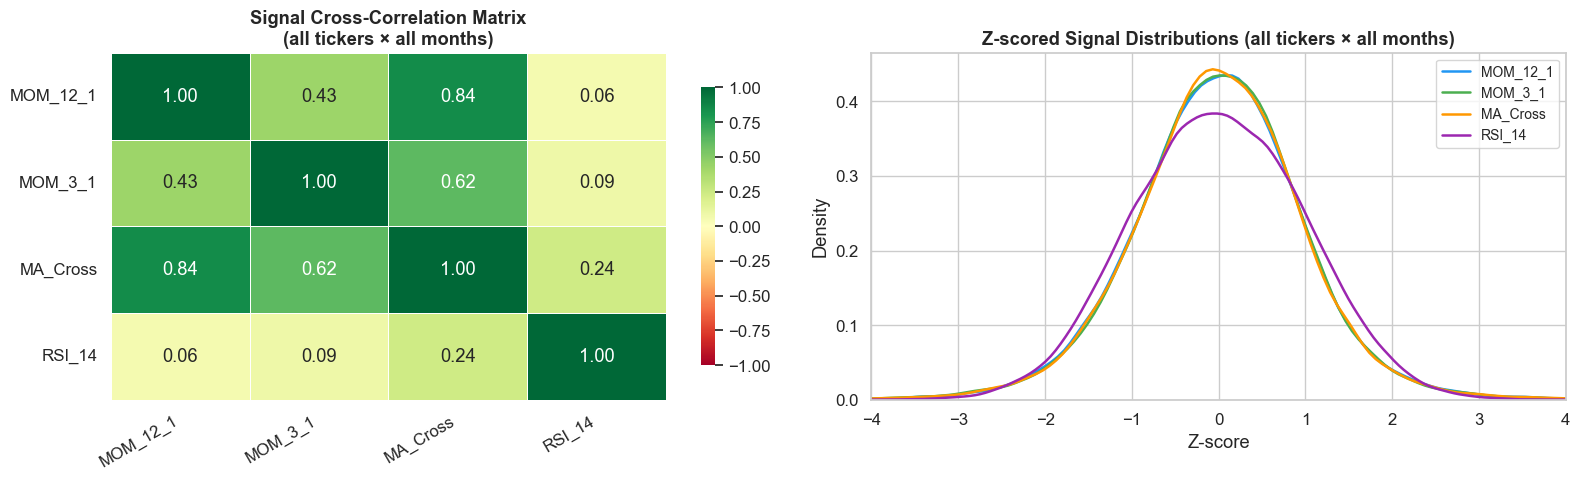

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# SIGNAL DIAGNOSTICS
# ─────────────────────────────────────────────────────────────────────────────
# Two charts:
#   1. Cross-correlation heatmap — are the signals redundant or complementary?
#   2. Faceted distribution — what does each signal look like across the universe?

# ── Prepare a stacked long-format DataFrame for correlations ──────────────────
# Stack each signal into a single column and join them side-by-side.
# This gives us one row per (month, ticker) observation — the right shape
# for computing cross-sectional correlations between signals.
stacked = pd.concat(
    {name: df.stack().rename(name) for name, df in signal_dict.items()},
    axis=1
).dropna()

corr_matrix = stacked.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Panel 1: Correlation heatmap ──────────────────────────────────────────────
# Values close to 0 mean the two signals capture independent information —
# good news for the Composite, which benefits from combining independent signals.
sns.heatmap(
    corr_matrix, ax=axes[0],
    annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
axes[0].set_title("Signal Cross-Correlation Matrix\n(all tickers × all months)",
                  fontweight="bold")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# ── Panel 2: Signal distributions ─────────────────────────────────────────────
# Z-score each signal before plotting so all four are on a comparable scale.
for name, colour in zip(SIGNAL_COLS, list(COLOURS.values())[:4]):
    z = z_score_cross_section(signal_dict[name]).stack().dropna()
    sns.kdeplot(z, ax=axes[1], label=name, color=colour, lw=1.8)

axes[1].set_xlim(-4, 4)
axes[1].set_title("Z-scored Signal Distributions (all tickers × all months)",
                  fontweight="bold")
axes[1].set_xlabel("Z-score")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 6. Walk-Forward Backtesting Engine

### How the backtest works

Each month, for a given signal:

1. **Rank** all stocks in the clean universe by their signal score
2. **Long portfolio** — buy the top 10 % equally weighted
3. **Short portfolio** — short the bottom 10 % equally weighted *(long-short mode only)*
4. **Hold** for one month, then collect the equal-weighted portfolio return
5. **Deduct transaction costs** — applied only to the fraction of the portfolio
   that changes hands (turnover) relative to the prior month

This "formation-month → holding-month" structure is the standard Jegadeesh-Titman
walk-forward design and eliminates any lookahead bias: signals are always computed
using only data available at the time of the trade.

### Transaction cost model

$$	ext{Cost}_t = rac{	ext{TRANSACTION\_COST\_BPS}}{10{,}000} 	imes 	ext{Turnover}_t$$

where $	ext{Turnover}_t$ is the fraction of the portfolio replaced in month $t$
(measured as 1 − overlap between this month's holdings and last month's holdings).
A monthly turnover of 100 % means the entire portfolio is replaced; 20 % means
only one-fifth changes.

### Long-only vs long-short

| Mode | Portfolio | Expected behaviour |
|------|-----------|-------------------|
| `long_only` | Top decile only | Lower return, lower vol — suitable for a long-only mandate |
| `long_short` | Top decile long + bottom decile short | Higher potential alpha, but requires short-selling |

### Benchmark

We compute the benchmark as the **equal-weighted average monthly return** of all
clean universe stocks — what you would earn by holding everything equally with no
signal at all. If `^GSPC` is present in the database we use it instead.

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# BACKTEST ENGINE
# ─────────────────────────────────────────────────────────────────────────────

def run_backtest(signal_df, returns_wide, mode="long_only",
                 top_q=TOP_DECILE, bot_q=BOTTOM_DECILE,
                 cost_bps=TRANSACTION_COST_BPS):
    """
    Walk-forward backtest for a single signal.

    Parameters
    ----------
    signal_df    : DataFrame [months × tickers] — the ranking signal
    returns_wide : DataFrame [months × tickers] — next-month log-returns
    mode         : 'long_only' or 'long_short'
    top_q        : quantile threshold for the long portfolio
    bot_q        : quantile threshold for the short portfolio
    cost_bps     : transaction cost in basis points, applied to turnover

    Returns
    -------
    Series of monthly portfolio returns indexed by month-end date.
    """
    cost_rate  = cost_bps / 10_000
    months     = signal_df.index.intersection(returns_wide.index)
    port_rets  = []
    prev_long  = set()
    prev_short = set()

    for i, month in enumerate(months[:-1]):           # signal at month, hold next month
        next_month = months[i + 1]
        scores     = signal_df.loc[month].dropna()

        if len(scores) < 20:                          # need enough stocks to form deciles
            continue

        # ── Rank and select portfolios ────────────────────────────────────────
        long_thresh  = scores.quantile(1 - top_q)
        long_stocks  = set(scores[scores >= long_thresh].index)

        # Compute next-month returns for the long portfolio
        long_ret = (
            returns_wide
            .loc[next_month, list(long_stocks)]
            .dropna()
            .mean()                                    # equal-weighted
        )

        # ── Transaction cost on long portfolio turnover ───────────────────────
        long_turnover = (
            1.0 if not prev_long
            else 1 - len(long_stocks & prev_long) / max(len(long_stocks), 1)
        )
        net_ret = long_ret - cost_rate * long_turnover

        if mode == "long_short":
            short_thresh  = scores.quantile(bot_q)
            short_stocks  = set(scores[scores <= short_thresh].index)
            short_ret = (
                returns_wide
                .loc[next_month, list(short_stocks)]
                .dropna()
                .mean()
            )
            short_turnover = (
                1.0 if not prev_short
                else 1 - len(short_stocks & prev_short) / max(len(short_stocks), 1)
            )
            # Long-short: profit from long, profit from short going down
            net_ret = (long_ret - cost_rate * long_turnover) -                       (short_ret - cost_rate * short_turnover)

            prev_short = short_stocks

        prev_long  = long_stocks
        port_rets.append({"month": next_month, "return": net_ret})

    return (
        pd.DataFrame(port_rets)
        .set_index("month")["return"]
    )


print("✓ Backtest engine defined.")

✓ Backtest engine defined.


In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# RUN ALL BACKTESTS
# ─────────────────────────────────────────────────────────────────────────────
# Align returns to the backtest window starting from BACKTEST_START.
bt_returns = (
    monthly_ret_wide
    .loc[BACKTEST_START:]
    .copy()
)

# ── Benchmark: equal-weighted universe return ──────────────────────────────────
# Check if ^GSPC is available in the database; fall back to equal-weighted mean.
con     = duckdb.connect(str(DB_PATH))
gspc_check = con.execute("""
    SELECT COUNT(*) AS n FROM daily_prices WHERE ticker = '^GSPC'
""").df()["n"].iloc[0]

if gspc_check > 0:
    gspc_daily = con.execute("""
        SELECT date, close FROM daily_prices
        WHERE ticker = '^GSPC' ORDER BY date
    """).df()
    con.close()
    gspc_daily["date"] = pd.to_datetime(gspc_daily["date"])
    benchmark = (
        gspc_daily
        .set_index("date")["close"]
        .resample(REBALANCE_FREQ).last()
        .apply(lambda x: np.log(x / x.shift(1)))
        .dropna()
        .loc[BACKTEST_START:]
        .rename("Benchmark")
    )
    print("✓ Using ^GSPC as benchmark.")
else:
    con.close()
    benchmark = bt_returns.mean(axis=1).rename("Benchmark")
    print("✓ ^GSPC not found — using equal-weighted universe return as benchmark.")

# ── Run 4 signals × 2 modes = 8 backtest series + benchmark ──────────────────
# Suffix convention: _LO = long-only, _LS = long-short
backtest_results = {}

for sig_name in SIGNAL_COLS + ["Composite"]:
    sig_df = all_signals[sig_name].loc[BACKTEST_START:]
    for mode in ["long_only", "long_short"]:
        # Fix: derive suffix explicitly — mode[:2] gives "lo" for both modes
        suffix = "LO" if mode == "long_only" else "LS"
        key    = f"{sig_name}_{suffix}"
        print(f"  Running {key} ...")
        backtest_results[key] = run_backtest(sig_df, bt_returns, mode=mode)

# Combine into a single DataFrame aligned on month-end dates
backtest_df = (
    pd.DataFrame(backtest_results)
    .join(benchmark, how="inner")
    .dropna(how="all")
)

print(f"\n✓ Backtests complete.")
print(f"  Shape    : {backtest_df.shape[0]} months × {backtest_df.shape[1]} strategies")
print(f"  Columns  : {backtest_df.columns.tolist()}")
print(f"  Period   : {backtest_df.index.min().date()}  →  {backtest_df.index.max().date()}")

✓ ^GSPC not found — using equal-weighted universe return as benchmark.
  Running MOM_12_1_LO ...
  Running MOM_12_1_LS ...
  Running MOM_3_1_LO ...
  Running MOM_3_1_LS ...
  Running MA_Cross_LO ...
  Running MA_Cross_LS ...
  Running RSI_14_LO ...
  Running RSI_14_LS ...
  Running Composite_LO ...
  Running Composite_LS ...

✓ Backtests complete.
  Shape    : 119 months × 11 strategies
  Columns  : ['MOM_12_1_LO', 'MOM_12_1_LS', 'MOM_3_1_LO', 'MOM_3_1_LS', 'MA_Cross_LO', 'MA_Cross_LS', 'RSI_14_LO', 'RSI_14_LS', 'Composite_LO', 'Composite_LS', 'Benchmark']
  Period   : 2016-05-31  →  2026-03-31


---
## 7. Machine Learning Layer

### Framing the problem

Can we improve on raw signal ranking by training a model to **predict which stocks
will land in the top decile next month**?

This is a **binary classification** problem:
- **Label = 1** — stock is in the top decile of returns in month t+1
- **Label = 0** — stock is not in the top decile

### Features

We use only the four momentum signals already computed in Section 5.
This is deliberately parsimonious: the goal is to understand whether combining
the signals non-linearly adds value over the simple Composite, not to build the
most complex model possible.

| Feature | Signal |
|---------|--------|
| MOM_12_1 | Z-scored cross-sectionally |
| MOM_3_1 | Z-scored cross-sectionally |
| MA_Cross | Z-scored cross-sectionally |
| RSI_14 | Z-scored cross-sectionally |

### Train / test split

We use a **70/30 temporal split** — first 70 % of months for training, last 30 % for
testing. This respects the time ordering of the data: no future information leaks
into the training set.

### Three models in order of complexity

| Model | Why include it |
|-------|----------------|
| **Logistic Regression** | Interpretable baseline — shows which signals matter linearly |
| **Random Forest** | Handles non-linear interactions; robust feature importance |
| **LightGBM** | Typically strongest on tabular financial data; fast |

No hyperparameter tuning. No SHAP. One clear output per model.

In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# BUILD ML DATASET
# ─────────────────────────────────────────────────────────────────────────────
# Features: z-scored signals at month t (formation month)
# Label   : 1 if the stock is in the top decile of next-month returns, else 0

# ── Stack signals into long format ────────────────────────────────────────────
z_signals = {name: z_score_cross_section(df) for name, df in signal_dict.items()}

signal_long = pd.concat(
    {name: df.stack().rename(name) for name, df in z_signals.items()},
    axis=1
).reset_index()
signal_long.columns = ["month", "ticker"] + SIGNAL_COLS

# ── Build forward returns: next month's return for each stock ─────────────────
fwd_ret = (
    monthly_ret_wide
    .stack()
    .reset_index()
    .rename(columns={"month_end": "month", "ticker": "ticker", 0: "fwd_ret"})
    # Shift the return back by one month to align with formation-month signals
)
# fwd_ret at month t = return earned holding from t to t+1
fwd_ret["month"] = fwd_ret.groupby("ticker")["month"].shift(-1)
fwd_ret = fwd_ret.dropna(subset=["month"])

# ── Merge signals with forward returns ───────────────────────────────────────
ml_df = (
    signal_long
    .merge(fwd_ret, on=["month", "ticker"], how="inner")
    .dropna()
)

# ── Create binary label: top decile of forward returns in each month ──────────
# We rank within each month so the label is always cross-sectional, not absolute.
ml_df["label"] = (
    ml_df
    .groupby("month")["fwd_ret"]
    .transform(lambda x: (x >= x.quantile(1 - TOP_DECILE)).astype(int))
)

print(f"ML dataset shape : {ml_df.shape}")
print(f"Label balance    : {ml_df['label'].mean():.2%} positive (target ≈ {TOP_DECILE:.0%})")

ML dataset shape : (48629, 8)
Label balance    : 10.17% positive (target ≈ 10%)


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN / TEST SPLIT (70 / 30 temporal)
# ─────────────────────────────────────────────────────────────────────────────
# Sort by month to ensure strict temporal ordering — no future data in training.
ml_df = ml_df.sort_values("month").reset_index(drop=True)

split_idx = int(len(ml_df) * 0.70)
train_df  = ml_df.iloc[:split_idx]
test_df   = ml_df.iloc[split_idx:]

X_train = train_df[SIGNAL_COLS].values
y_train = train_df["label"].values
X_test  = test_df[SIGNAL_COLS].values
y_test  = test_df["label"].values

# Scale features — required for Logistic Regression; harmless for tree models
scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)    # fit on train only — no leakage
X_test_s  = scaler.transform(X_test)

split_month = ml_df.iloc[split_idx]["month"]
print(f"Training period  : {ml_df.iloc[0]['month'].date()}  →  {train_df.iloc[-1]['month'].date()}")
print(f"Test period      : {split_month.date()}  →  {ml_df.iloc[-1]['month'].date()}")
print(f"Train samples    : {len(train_df):,}  |  Test samples: {len(test_df):,}")

Training period  : 2017-04-30  →  2023-07-31
Test period      : 2023-07-31  →  2026-03-31
Train samples    : 34,040  |  Test samples: 14,589


In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN THREE MODELS
# ─────────────────────────────────────────────────────────────────────────────

# ── Logistic Regression (L2 regularised baseline) ─────────────────────────────
lr = LogisticRegression(C=1.0, max_iter=500, random_state=42)
lr.fit(X_train_s, y_train)
lr_prob = lr.predict_proba(X_test_s)[:, 1]
lr_pred = lr.predict(X_test_s)

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)          # tree models don't need scaled features
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

# ── LightGBM ──────────────────────────────────────────────────────────────────
lgbm = lgb.LGBMClassifier(n_estimators=100, random_state=42,
                           verbose=-1, n_jobs=-1)
lgbm.fit(X_train, y_train)
lgbm_prob = lgbm.predict_proba(X_test)[:, 1]
lgbm_pred = lgbm.predict(X_test)

# ── Collect evaluation metrics ────────────────────────────────────────────────
metrics = {
    "Logistic Regression": {
        "AUC-ROC": roc_auc_score(y_test, lr_prob),
        "F1 Score": f1_score(y_test, lr_pred),
    },
    "Random Forest": {
        "AUC-ROC": roc_auc_score(y_test, rf_prob),
        "F1 Score": f1_score(y_test, rf_pred),
    },
    "LightGBM": {
        "AUC-ROC": roc_auc_score(y_test, lgbm_prob),
        "F1 Score": f1_score(y_test, lgbm_pred),
    },
}

metrics_df = pd.DataFrame(metrics).T
print("Model evaluation on test set:")
display(
    metrics_df
    .style
    .format("{:.4f}")
    .set_caption("AUC-ROC and F1 Score — higher is better")
    .background_gradient(cmap="Greens", axis=0)
)

Model evaluation on test set:


,AUC-ROC,F1 Score
Logistic Regression,0.8829,0.3556
Random Forest,0.8643,0.3925
LightGBM,0.8826,0.3832


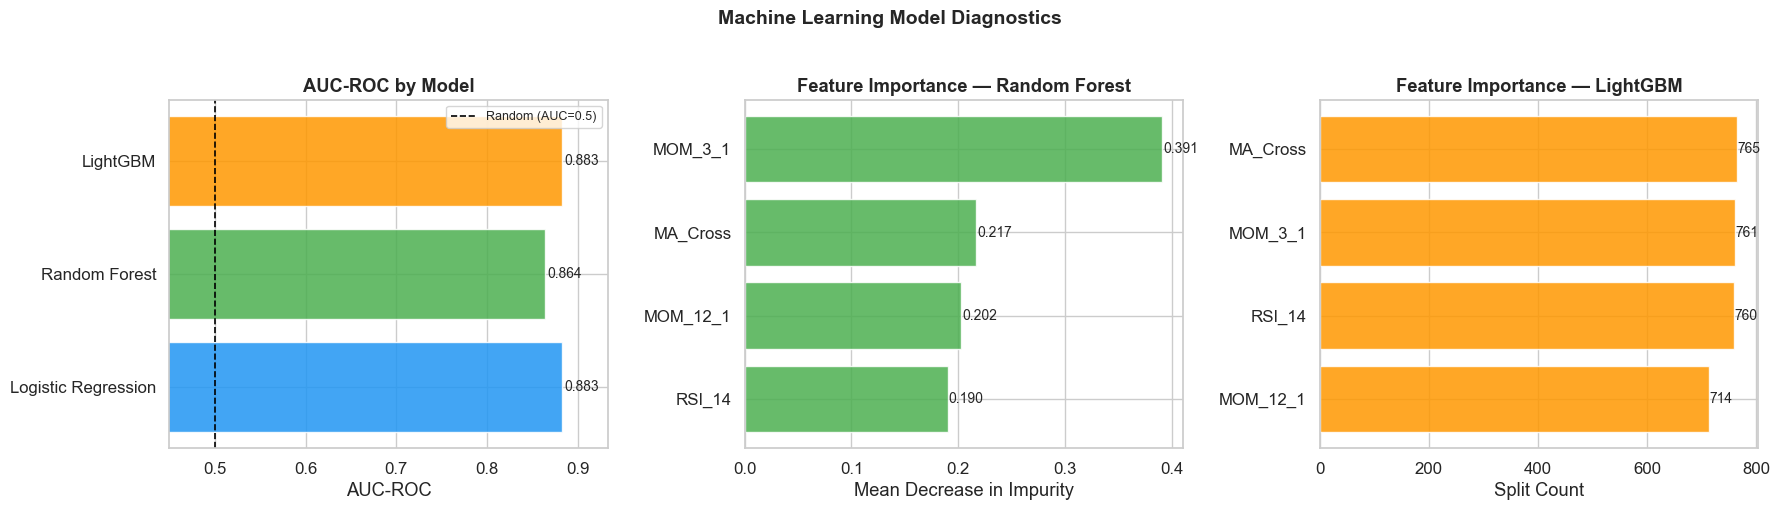

In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# ML DIAGNOSTICS — AUC/F1 BAR CHART + FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: AUC comparison ───────────────────────────────────────────────────
auc_vals = [v["AUC-ROC"] for v in metrics.values()]
models   = list(metrics.keys())
colours  = ["#2196F3", "#4CAF50", "#FF9800"]

axes[0].barh(models, auc_vals, color=colours, alpha=0.85)
axes[0].axvline(0.5, color="black", lw=1.2, ls="--", label="Random (AUC=0.5)")
axes[0].set_xlim(0.45, min(1.0, max(auc_vals) + 0.05))
axes[0].set_title("AUC-ROC by Model", fontweight="bold")
axes[0].set_xlabel("AUC-ROC")
axes[0].legend(fontsize=9)
for i, v in enumerate(auc_vals):
    axes[0].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=10)

# ── Panel 2: Random Forest feature importance ─────────────────────────────────
rf_imp = pd.Series(rf.feature_importances_, index=SIGNAL_COLS).sort_values()
axes[1].barh(rf_imp.index, rf_imp.values, color="#4CAF50", alpha=0.85)
axes[1].set_title("Feature Importance — Random Forest", fontweight="bold")
axes[1].set_xlabel("Mean Decrease in Impurity")
for i, v in enumerate(rf_imp.values):
    axes[1].text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=10)

# ── Panel 3: LightGBM feature importance ─────────────────────────────────────
lgbm_imp = pd.Series(lgbm.feature_importances_, index=SIGNAL_COLS).sort_values()
axes[2].barh(lgbm_imp.index, lgbm_imp.values, color="#FF9800", alpha=0.85)
axes[2].set_title("Feature Importance — LightGBM", fontweight="bold")
axes[2].set_xlabel("Split Count")
for i, v in enumerate(lgbm_imp.values):
    axes[2].text(v + 0.5, i, f"{v:.0f}", va="center", fontsize=10)

plt.suptitle("Machine Learning Model Diagnostics", fontsize=14,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [51]:
# ─────────────────────────────────────────────────────────────────────────────
# ML SIGNAL BACKTEST
# ─────────────────────────────────────────────────────────────────────────────
# Use the best model's predicted probability as a ranking signal and run it
# through the same backtest engine as Section 6.
#
# The best model is selected automatically by AUC score.
# Predicted probabilities become the signal: higher probability of being
# top-decile next month → higher ranking in the portfolio.

best_model_name = max(metrics, key=lambda k: metrics[k]["AUC-ROC"])
print(f"Best model by AUC: {best_model_name}")

# Map predictions back to (month, ticker) pairs using the test set
if best_model_name == "Logistic Regression":
    best_prob = lr_prob
elif best_model_name == "Random Forest":
    best_prob = rf_prob
else:
    best_prob = lgbm_prob

# Build a wide-format signal DataFrame from ML probabilities
ml_signal_long = test_df[["month", "ticker"]].copy()
ml_signal_long["ml_prob"] = best_prob

ml_signal_wide = (
    ml_signal_long
    .pivot(index="month", columns="ticker", values="ml_prob")
)

# Align to the backtest returns index
common = bt_returns.index.intersection(ml_signal_wide.index)
ml_ret_aligned = bt_returns.loc[common]

# Run backtest with both modes
for mode in ["long_only", "long_short"]:
    suffix = "LO" if mode == "long_only" else "LS"
    key    = f"ML_{suffix}"
    print(f"  Running {key} ...")
    backtest_results[key] = run_backtest(
        ml_signal_wide, ml_ret_aligned, mode=mode
    )

# Append ML results to backtest_df
backtest_df = (
    pd.DataFrame(backtest_results)
    .join(benchmark, how="inner")
    .dropna(how="all")
)

print(f"\n✓ ML backtest added. Total strategies: {backtest_df.shape[1]}")

Best model by AUC: Logistic Regression
  Running ML_LO ...
  Running ML_LS ...

✓ ML backtest added. Total strategies: 13


---
## 8. Performance Metrics & Visualisation

### Metrics

For each strategy we compute six performance metrics — the standard toolkit
for evaluating quantitative strategies:

| Metric | Formula | What it measures |
|--------|---------|-----------------|
| **Annualised Return** | $\bar{r} \times 12$ | Average annual profit |
| **Annualised Volatility** | $\sigma \times \sqrt{12}$ | Year-on-year risk |
| **Sharpe Ratio** | $(R_{ann} - R_f) / \sigma_{ann}$ | Return per unit of risk |
| **Max Drawdown** | $\max_t \left(\frac{\text{Peak}_t - W_t}{\text{Peak}_t}\right)$ | Worst peak-to-trough loss |
| **Calmar Ratio** | $R_{ann} / |\text{Max Drawdown}|$ | Return per unit of drawdown |
| **Win Rate** | % months with positive return | Consistency |

### Visualisations

A `GridSpec` dashboard with four panels:
- **Top row (full width):** cumulative return curves — all strategies vs benchmark
- **Bottom left:** rolling 12-month Sharpe ratio — how stable is performance over time?
- **Bottom centre:** drawdown profiles (underwater equity curves)
- **Bottom right:** bar chart comparing Sharpe and Calmar across strategies

In [52]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE PERFORMANCE METRICS
# ─────────────────────────────────────────────────────────────────────────────

def performance_metrics(returns_series, rf=RF_ANNUAL):
    """
    Compute standard performance metrics for a monthly return series.

    Parameters
    ----------
    returns_series : pd.Series of monthly log-returns
    rf             : annual risk-free rate

    Returns
    -------
    dict of metric name → value
    """
    r  = returns_series.dropna()
    rf_monthly = rf / 12

    ann_ret  = r.mean() * 12
    ann_vol  = r.std() * np.sqrt(12)
    sharpe   = (ann_ret - rf) / ann_vol if ann_vol > 0 else np.nan

    # ── Max drawdown ──────────────────────────────────────────────────────────
    # Cumulative wealth index; drawdown = (peak - current) / peak
    wealth   = (1 + r).cumprod()
    peak     = wealth.cummax()
    dd       = (wealth - peak) / peak
    max_dd   = dd.min()

    calmar   = ann_ret / abs(max_dd) if max_dd < 0 else np.nan
    win_rate = (r > 0).mean()

    return {
        "Ann. Return"  : ann_ret,
        "Ann. Vol"     : ann_vol,
        "Sharpe"       : sharpe,
        "Max Drawdown" : max_dd,
        "Calmar"       : calmar,
        "Win Rate"     : win_rate,
    }


metrics_rows = {col: performance_metrics(backtest_df[col]) for col in backtest_df.columns}
perf_df = (
    pd.DataFrame(metrics_rows)
    .T
    .sort_values("Sharpe", ascending=False)
)

display(
    perf_df
    .style
    .format({
        "Ann. Return"  : "{:.2%}",
        "Ann. Vol"     : "{:.2%}",
        "Sharpe"       : "{:.2f}",
        "Max Drawdown" : "{:.2%}",
        "Calmar"       : "{:.2f}",
        "Win Rate"     : "{:.2%}",
    })
    .set_caption("Strategy Performance Summary (sorted by Sharpe Ratio)")
    .background_gradient(subset=["Sharpe", "Calmar"], cmap="RdYlGn")
    .background_gradient(subset=["Max Drawdown"], cmap="RdYlGn_r")
)

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Calmar,Win Rate
Composite_LO,14.06%,17.51%,0.57,-21.91%,0.64,66.39%
MA_Cross_LO,14.02%,17.86%,0.56,-24.98%,0.56,64.71%
MOM_3_1_LO,13.58%,18.05%,0.53,-24.42%,0.56,65.52%
MOM_12_1_LO,13.48%,18.88%,0.50,-23.65%,0.57,62.62%
RSI_14_LO,10.73%,14.40%,0.47,-19.97%,0.54,64.71%
Benchmark,11.52%,16.09%,0.47,-26.44%,0.44,67.23%
ML_LO,7.43%,15.84%,0.22,-14.71%,0.50,53.12%
MOM_12_1_LS,3.70%,17.07%,-0.02,-35.15%,0.11,49.53%
MA_Cross_LS,3.68%,17.83%,-0.02,-28.62%,0.13,49.58%
Composite_LS,1.59%,17.43%,-0.14,-28.86%,0.06,52.94%


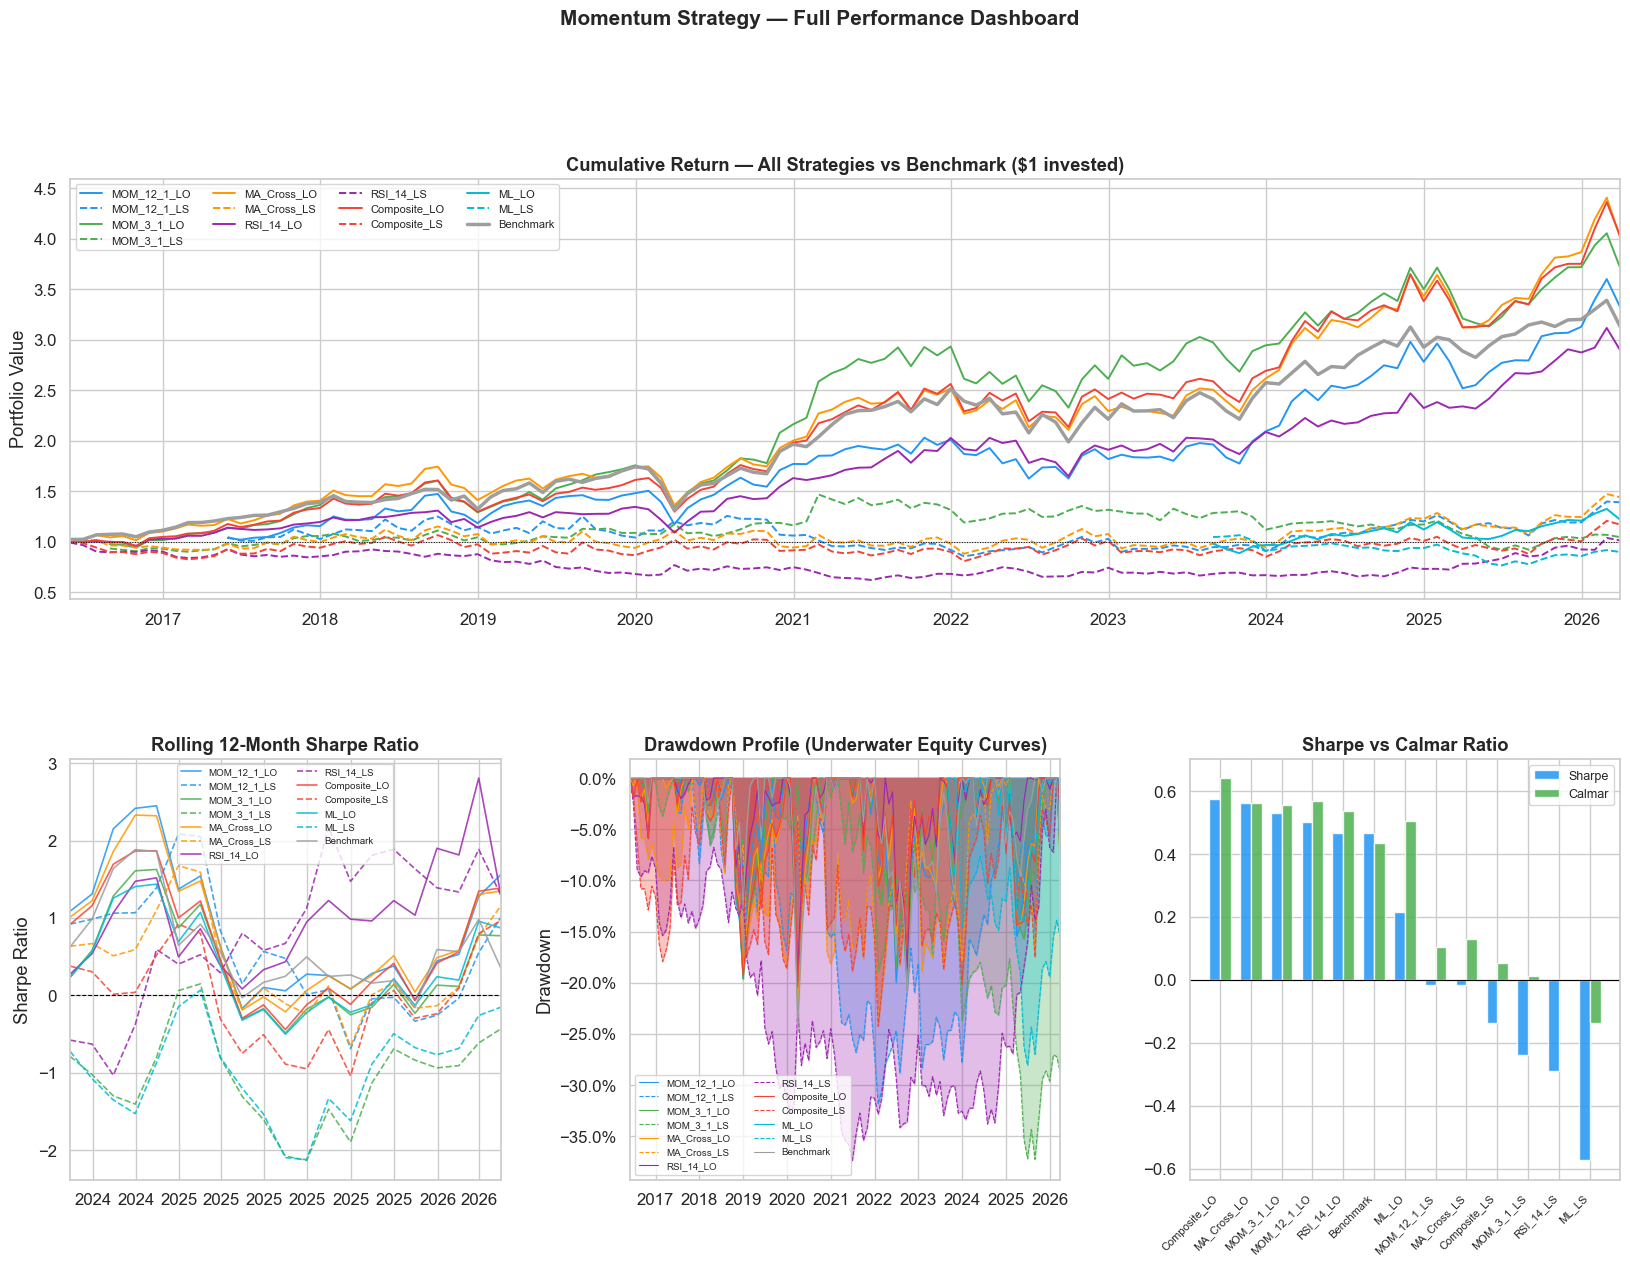

In [54]:
# ─────────────────────────────────────────────────────────────────────────────
# PERFORMANCE DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────
# GridSpec layout:
#   Row 0 (full width) : cumulative returns
#   Row 1 left         : rolling 12-month Sharpe
#   Row 1 centre       : drawdown profiles
#   Row 1 right        : Sharpe & Calmar bar chart

fig = plt.figure(figsize=(20, 13))
gs  = GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.3)

ax_cum = fig.add_subplot(gs[0, :])
ax_sr  = fig.add_subplot(gs[1, 0])
ax_dd  = fig.add_subplot(gs[1, 1])
ax_bar = fig.add_subplot(gs[1, 2])

# ── Helper: pick line style ────────────────────────────────────────────────────
def get_colour(col):
    """Return a consistent colour for each strategy column."""
    for key, c in COLOURS.items():
        if key in col:
            return c
    return "#607D8B"   # default slate grey


def get_ls(col):
    """Long-short strategies use dashed lines; long-only use solid."""
    return "--" if "_LS" in col else "-"


# ── Panel 1: Cumulative returns ────────────────────────────────────────────────
# exp(cumsum(log-returns)) converts monthly log-returns to a wealth index
# starting at 1.0 — what $1 invested at inception grows to.
cum_ret = (
    backtest_df
    .cumsum()
    .apply(np.exp)
)

for col in cum_ret.columns:
    lw  = 2.5 if col == "Benchmark" else 1.4
    ax_cum.plot(cum_ret.index, cum_ret[col],
                color=get_colour(col), ls=get_ls(col),
                lw=lw, label=col)

ax_cum.axhline(1, color="black", lw=0.7, ls=":")
ax_cum.set_title("Cumulative Return — All Strategies vs Benchmark ($1 invested)",
                 fontweight="bold")
ax_cum.set_ylabel("Portfolio Value")
ax_cum.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_cum.legend(ncol=4, fontsize=8, loc="upper left")
ax_cum.margins(x=0)

# ── Panel 2: Rolling 12-month Sharpe ──────────────────────────────────────────
# Rolling Sharpe shows whether performance is consistent or concentrated
# in a few lucky months.  Sustained positive values indicate a robust strategy.
roll_sharpe = (
    backtest_df
    .rolling(12)
    .apply(lambda r: (r.mean() * 12 - RF_ANNUAL) / (r.std() * np.sqrt(12)))
    .dropna()
)

for col in roll_sharpe.columns:
    ax_sr.plot(roll_sharpe.index, roll_sharpe[col],
               color=get_colour(col), ls=get_ls(col),
               lw=1.2, label=col, alpha=0.85)

ax_sr.axhline(0, color="black", lw=0.8, ls="--")
ax_sr.set_title("Rolling 12-Month Sharpe Ratio", fontweight="bold")
ax_sr.set_ylabel("Sharpe Ratio")
ax_sr.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_sr.legend(fontsize=7, ncol=2)
ax_sr.margins(x=0)

# ── Panel 3: Drawdown profiles (underwater equity curves) ─────────────────────
# At each date, how far below the previous all-time high is the portfolio?
# The curve sits at 0 when at a new high and dips negative during losses.
# Deep, prolonged dips are far worse for investors than short sharp drops.
for col in cum_ret.columns:
    w    = cum_ret[col]
    dd   = (w - w.cummax()) / w.cummax()
    ax_dd.fill_between(dd.index, dd.values, 0,
                       alpha=0.3, color=get_colour(col))
    ax_dd.plot(dd.index, dd.values,
               color=get_colour(col), ls=get_ls(col),
               lw=0.8, label=col)

ax_dd.set_title("Drawdown Profile (Underwater Equity Curves)", fontweight="bold")
ax_dd.set_ylabel("Drawdown")
ax_dd.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_dd.legend(fontsize=7, ncol=2)
ax_dd.margins(x=0)

# ── Panel 4: Sharpe and Calmar bar chart ──────────────────────────────────────
# Side-by-side bars let us compare risk-adjusted return (Sharpe) with
# drawdown-adjusted return (Calmar) across all strategies at a glance.
bar_df = perf_df[["Sharpe", "Calmar"]].dropna()
x      = np.arange(len(bar_df))
width  = 0.35

ax_bar.bar(x - width/2, bar_df["Sharpe"],  width, label="Sharpe",
           color="#2196F3", alpha=0.85)
ax_bar.bar(x + width/2, bar_df["Calmar"],  width, label="Calmar",
           color="#4CAF50", alpha=0.85)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(bar_df.index, rotation=45, ha="right", fontsize=8)
ax_bar.axhline(0, color="black", lw=0.8)
ax_bar.set_title("Sharpe vs Calmar Ratio", fontweight="bold")
ax_bar.legend(fontsize=9)

plt.suptitle("Momentum Strategy — Full Performance Dashboard",
             fontsize=15, fontweight="bold", y=1.01)
plt.show()

---
## 9. Fama-French 3-Factor Risk Adjustment

### Why risk-adjust?

A momentum strategy naturally buys recent winners. Recent winners tend to be
large-cap growth stocks — which means part of our return may simply be compensation
for tilting toward those kinds of stocks, not genuine momentum alpha.

The Fama-French 3-factor model decomposes our portfolio's excess return into:

$$R_{p,t} - R_{f,t} = \alpha + \beta_1 \cdot \text{MktRF}_t + \beta_2 \cdot \text{SMB}_t + \beta_3 \cdot \text{HML}_t + \varepsilon_t$$

| Term | Meaning in plain English |
|------|--------------------------|
| $\alpha$ | Return the strategy earns **after** accounting for market, size, and value tilts — pure momentum skill |
| $\beta_1$ (Market) | How much the strategy simply follows the broad market |
| $\beta_2$ (SMB) | Tilt toward small caps (+) or large caps (−) |
| $\beta_3$ (HML) | Tilt toward value stocks (+) or growth stocks (−) |

A statistically significant positive $\alpha$ (t-stat > 2) means the strategy
generates returns that cannot be explained by standard risk factors — genuine alpha.

In [56]:
# ─────────────────────────────────────────────────────────────────────────────
# DOWNLOAD FAMA-FRENCH 3-FACTOR DATA
# ─────────────────────────────────────────────────────────────────────────────
# Kenneth French publishes monthly factor returns as a free ZIP/CSV on Dartmouth.
# Columns: Mkt-RF, SMB, HML, RF — all in percent (we divide by 100).
#
# Parsing strategy:
#   The CSV contains two sections — monthly (YYYYMM rows) and annual (YYYY rows).
#   We keep only rows where the date column is exactly 6 digits (YYYYMM format).
#   This cleanly separates monthly from annual rows without relying on row position.

import zipfile, io

FF_URL = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
    "F-F_Research_Data_Factors_CSV.zip"
)

ff_df = None   # initialise so the regression cell can check safely

print("Downloading Fama-French 3-factor data ...")

try:
    resp = requests.get(FF_URL, timeout=30)
    resp.raise_for_status()                      # raises if HTTP error (4xx, 5xx)

    # ── Unzip and read the CSV ────────────────────────────────────────────────
    zf       = zipfile.ZipFile(io.BytesIO(resp.content))
    csv_name = zf.namelist()[0]                  # only one file inside the ZIP
    raw_text = zf.read(csv_name).decode("utf-8", errors="replace")

    # ── Parse line by line ────────────────────────────────────────────────────
    # A valid monthly row has exactly 5 comma-separated fields and the first
    # field is a 6-digit integer (YYYYMM).  Annual rows are 4 digits (YYYY).
    # Header/footer lines fail both checks cleanly.
    data_lines = []
    for line in raw_text.splitlines():
        parts = [p.strip() for p in line.split(",")]
        if len(parts) != 5:
            continue
        date_str = parts[0].strip()
        if len(date_str) == 6 and date_str.isdigit():   # monthly row only
            data_lines.append(parts)

    if not data_lines:
        raise ValueError("No monthly data rows found — the CSV format may have changed.")

    # ── Build DataFrame ───────────────────────────────────────────────────────
    ff_raw = pd.DataFrame(data_lines, columns=["yyyymm", "Mkt_RF", "SMB", "HML", "RF"])

    ff_df = (
        ff_raw
        .assign(
            date   = lambda x: pd.to_datetime(x["yyyymm"].str.strip(), format="%Y%m")
                                + pd.offsets.MonthEnd(0),
            Mkt_RF = lambda x: pd.to_numeric(x["Mkt_RF"], errors="coerce") / 100,
            SMB    = lambda x: pd.to_numeric(x["SMB"],    errors="coerce") / 100,
            HML    = lambda x: pd.to_numeric(x["HML"],    errors="coerce") / 100,
            RF     = lambda x: pd.to_numeric(x["RF"],     errors="coerce") / 100,
        )
        .dropna(subset=["Mkt_RF"])          # drop any rows that failed numeric conversion
        .set_index("date")
        [["Mkt_RF", "SMB", "HML", "RF"]]
    )

    # ── Filter to backtest window ─────────────────────────────────────────────
    ff_df = ff_df.loc[ff_df.index >= pd.Timestamp(BACKTEST_START)]

    if ff_df.empty:
        raise ValueError(f"No FF data found after {BACKTEST_START}.")

    print(f"✓ Fama-French data loaded.")
    print(f"  Rows   : {len(ff_df)} months")
    print(f"  Range  : {ff_df.index.min().date()}  →  {ff_df.index.max().date()}")
    print(f"  Sample :")
    display(ff_df.tail(3).style.format("{:.4f}"))

except requests.exceptions.ConnectionError:
    print("⚠  No internet connection — cannot download FF data.")
    print("   Section 9 regression will be skipped.")

except requests.exceptions.Timeout:
    print("⚠  Request timed out — try again or check your connection.")

except Exception as e:
    print(f"⚠  FF download failed: {type(e).__name__}: {e}")
    print("   Section 9 regression will be skipped.")

✓ Fama-French data loaded.
  Rows   : 133 months
  Range  : 2015-01-31  →  2026-01-31
  Sample :


,Mkt_RF,SMB,HML,RF
date,,,,
2025-11-30 00:00:00,-0.0013,0.0038,0.0376,0.0030
2025-12-31 00:00:00,-0.0036,-0.0106,0.0242,0.0034
2026-01-31 00:00:00,0.0102,0.0221,0.0370,0.0030


In [59]:
# ─────────────────────────────────────────────────────────────────────────────
# OLS REGRESSION — NUMPY IMPLEMENTATION
# ─────────────────────────────────────────────────────────────────────────────
# We implement OLS from scratch using numpy to avoid adding statsmodels as a
# dependency.  The key outputs are:
#   alpha      : intercept (annualised)
#   betas      : factor loadings [Mkt-RF, SMB, HML]
#   t-stats    : coefficient / standard error
#   p-values   : two-tailed using the t-distribution
#   R²         : fraction of variance explained by the three factors

def ols_regression(y, X):
    """
    OLS regression: y = X @ beta + eps
    X should already include the intercept column.

    Returns dict with keys: beta, se, t_stat, p_value, r_squared, alpha_annual
    """
    n, k  = X.shape
    beta  = np.linalg.lstsq(X, y, rcond=None)[0]

    y_hat = X @ beta
    resid = y - y_hat
    s2    = (resid @ resid) / (n - k)            # residual variance
    var_b = s2 * np.linalg.inv(X.T @ X)          # covariance matrix of beta
    se    = np.sqrt(np.diag(var_b))

    t_stat  = beta / se
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=n - k))

    ss_res  = resid @ resid
    ss_tot  = ((y - y.mean()) ** 2).sum()
    r2      = 1 - ss_res / ss_tot

    return {
        "beta"        : beta,
        "se"          : se,
        "t_stat"      : t_stat,
        "p_value"     : p_value,
        "r_squared"   : r2,
    }

# ── Check what columns exist in backtest_df ───────────────────────────────────
print("backtest_df columns:")
print(backtest_df.columns.tolist())
print()

# ── Check what ls_cols resolves to ────────────────────────────────────────────
ls_cols = [c for c in backtest_df.columns if "_LS" in c or c == "ML_LS"]
print(f"ls_cols found : {ls_cols}")
# ─────────────────────────────────────────────────────────────────────────────
# FAMA-FRENCH REGRESSION LOOP
# ─────────────────────────────────────────────────────────────────────────────
# Runs OLS regression for every strategy in backtest_df (excluding Benchmark).
# Works regardless of whether _LO or _LS columns exist — no hardcoded names.
#
# For each strategy:
#   y = strategy monthly return − risk-free rate (excess return)
#   X = [1, Mkt-RF, SMB, HML]   (intercept + 3 factors)
#
# Key output: alpha — the return left over after stripping out market, size,
# and value factor exposure.  Significant if |t-stat| > 2.0.

if ff_df is None:
    print("⚠  ff_df is None — FF data was not downloaded. Skipping regression.")

else:
    # ── Identify all strategy columns ─────────────────────────────────────────
    strategy_cols = [c for c in backtest_df.columns if c != "Benchmark"]
    print(f"Running FF regression on {len(strategy_cols)} strategies:")
    print("  " + "  |  ".join(strategy_cols))
    print()

    # ── Standardise both indexes to month-end Timestamps ─────────────────────
    # The .join() requires identical index values on both sides.
    # pd.offsets.MonthEnd(0) snaps any date to the last day of its month.
    bt_clean       = backtest_df.copy()
    bt_clean.index = pd.to_datetime(bt_clean.index) + pd.offsets.MonthEnd(0)
    ff_df.index    = pd.to_datetime(ff_df.index)    + pd.offsets.MonthEnd(0)

    results = []

    for col in strategy_cols:
        # ── Merge strategy returns with FF factors on date index ──────────────
        merged = (
            bt_clean[[col]]
            .rename(columns={col: "ret"})
            .join(ff_df, how="inner")    # keeps only months present in both
            .dropna()
        )

        if len(merged) < 12:
            # Need at least 12 months to estimate 4 parameters reliably
            print(f"  ⚠  {col}: only {len(merged)} overlapping months — skipping.")
            continue

        # ── Build regression inputs ───────────────────────────────────────────
        y = (merged["ret"] - merged["RF"]).values    # excess return
        X = np.column_stack([
            np.ones(len(merged)),        # intercept → gives us alpha
            merged["Mkt_RF"].values,     # market factor loading
            merged["SMB"].values,        # size factor loading
            merged["HML"].values,        # value factor loading
        ])

        res = ols_regression(y, X)

        results.append({
            "Strategy"      : col,
            "Ann. Alpha"    : res["beta"][0] * 12,    # monthly alpha → annualised
            "Alpha t-stat"  : res["t_stat"][0],
            "Significant?"  : "✓ Yes" if abs(res["t_stat"][0]) > 2 else "✗ No",
            "Market β"      : res["beta"][1],
            "Size β (SMB)"  : res["beta"][2],
            "Value β (HML)" : res["beta"][3],
            "R²"            : res["r_squared"],
            "N months"      : len(merged),
        })

        print(f"  ✓  {col:<30}  alpha={res['beta'][0]*12:.2%}  "
              f"t={res['t_stat'][0]:.2f}  R²={res['r_squared']:.2f}  "
              f"({len(merged)} months)")

    # ── Display results table ─────────────────────────────────────────────────
    if not results:
        print()
        print("⚠  No regression results produced.")
        print("   Most likely cause: no overlapping dates between backtest_df and ff_df.")
        print(f"   backtest_df : {bt_clean.index.min().date()} → "
              f"{bt_clean.index.max().date()}")
        print(f"   ff_df       : {ff_df.index.min().date()} → "
              f"{ff_df.index.max().date()}")

    else:
        ff_results_df = pd.DataFrame(results).set_index("Strategy")

        print()
        display(
            ff_results_df
            .drop(columns=["N months"])
            .style
            .format({
                "Ann. Alpha"    : "{:.2%}",
                "Alpha t-stat"  : "{:.2f}",
                "Market β"      : "{:.2f}",
                "Size β (SMB)"  : "{:.2f}",
                "Value β (HML)" : "{:.2f}",
                "R²"            : "{:.2f}",
            })
            .set_caption(
                "Fama-French 3-Factor Regression  |  "
                "Ann. Alpha = annual return unexplained by market, size, and value factors.  "
                "Significant if |Alpha t-stat| > 2.0"
            )
            .background_gradient(subset=["Ann. Alpha"], cmap="RdYlGn")
            .background_gradient(subset=["R²"], cmap="Blues")
        )

backtest_df columns:
['MOM_12_1_LO', 'MOM_12_1_LS', 'MOM_3_1_LO', 'MOM_3_1_LS', 'MA_Cross_LO', 'MA_Cross_LS', 'RSI_14_LO', 'RSI_14_LS', 'Composite_LO', 'Composite_LS', 'ML_LO', 'ML_LS', 'Benchmark']

ls_cols found : ['MOM_12_1_LS', 'MOM_3_1_LS', 'MA_Cross_LS', 'RSI_14_LS', 'Composite_LS', 'ML_LS']
Running FF regression on 12 strategies:
  MOM_12_1_LO  |  MOM_12_1_LS  |  MOM_3_1_LO  |  MOM_3_1_LS  |  MA_Cross_LO  |  MA_Cross_LS  |  RSI_14_LO  |  RSI_14_LS  |  Composite_LO  |  Composite_LS  |  ML_LO  |  ML_LS

  ✓  MOM_12_1_LO                     alpha=-0.63%  t=-0.21  R²=0.79  (105 months)
  ✓  MOM_12_1_LS                     alpha=2.34%  t=0.43  R²=0.19  (105 months)
  ✓  MOM_3_1_LO                      alpha=0.19%  t=0.06  R²=0.77  (114 months)
  ✓  MOM_3_1_LS                      alpha=0.55%  t=0.11  R²=0.06  (114 months)
  ✓  MA_Cross_LO                     alpha=0.24%  t=0.08  R²=0.73  (117 months)
  ✓  MA_Cross_LS                     alpha=3.77%  t=0.68  R²=0.15  (117 months)
  ✓ 

,Ann. Alpha,Alpha t-stat,Significant?,Market β,Size β (SMB),Value β (HML),R²
Strategy,,,,,,,
MOM_12_1_LO,-0.63%,-0.21,✗ No,0.99,0.10,0.05,0.79
MOM_12_1_LS,2.34%,0.43,✗ No,-0.21,-0.16,-0.43,0.19
MOM_3_1_LO,0.19%,0.06,✗ No,0.96,0.14,0.10,0.77
MOM_3_1_LS,0.55%,0.11,✗ No,-0.16,0.00,-0.20,0.06
MA_Cross_LO,0.24%,0.08,✗ No,0.95,0.07,0.08,0.73
MA_Cross_LS,3.77%,0.68,✗ No,-0.25,-0.20,-0.33,0.15
RSI_14_LO,-1.45%,-0.58,✗ No,0.78,-0.08,0.14,0.73
RSI_14_LS,-0.19%,-0.05,✗ No,-0.25,-0.18,-0.14,0.16
Composite_LO,0.19%,0.06,✗ No,0.93,0.02,0.07,0.71


---
## 10. Current Stock Screener

This section produces a real-time ranked view of the clean universe based on the
most recent complete month of data.

Each stock receives a **composite momentum score** — the equal-weighted average
of z-scored individual signal values. A score above zero means the stock ranks
above the median on momentum; a high positive score means multiple signals agree
it is a strong momentum candidate.

### Output

- **Top 10** — highest composite scores: long candidates
- **Bottom 10** — lowest composite scores: short candidates
- Horizontal bar chart: green for top 10, red for bottom 10

In [60]:
# ─────────────────────────────────────────────────────────────────────────────
# CURRENT SNAPSHOT — MOST RECENT COMPLETE MONTH
# ─────────────────────────────────────────────────────────────────────────────
# Use the last date available in the signal DataFrames.
# All signals are already z-scored cross-sectionally in z_signals (from Section 7).

latest_month = sig_composite.index.max()
print(f"Screener date (most recent complete month): {latest_month.date()}")

# ── Build the screener DataFrame ──────────────────────────────────────────────
screener = (
    pd.DataFrame({
        "MOM_12_1"  : z_score_cross_section(sig_mom12).loc[latest_month],
        "MOM_3_1"   : z_score_cross_section(sig_mom3).loc[latest_month],
        "MA_Cross"  : z_score_cross_section(sig_ma).loc[latest_month],
        "RSI_14"    : z_score_cross_section(sig_rsi).loc[latest_month],
    })
    .assign(Composite=sig_composite.loc[latest_month])
    .dropna()
    .sort_values("Composite", ascending=False)
    .rename_axis("Ticker")
    .reset_index()
)

top10    = screener.head(10)
bottom10 = screener.tail(10).sort_values("Composite")

print(f"\nUniverse size this month: {len(screener)} tickers")

# ── Display top 10 and bottom 10 ──────────────────────────────────────────────
print("\n--- TOP 10 (Long Candidates) ---")
display(
    top10
    .style
    .format({c: "{:.2f}" for c in SIGNAL_COLS + ["Composite"]})
    .background_gradient(subset=["Composite"], cmap="Greens")
    .set_caption("Top 10 Momentum Stocks — Long Candidates")
    .hide(axis="index")
)

print("\n--- BOTTOM 10 (Short Candidates) ---")
display(
    bottom10
    .style
    .format({c: "{:.2f}" for c in SIGNAL_COLS + ["Composite"]})
    .background_gradient(subset=["Composite"], cmap="Reds_r")
    .set_caption("Bottom 10 Momentum Stocks — Short Candidates")
    .hide(axis="index")
)

Screener date (most recent complete month): 2026-03-31

Universe size this month: 451 tickers

--- TOP 10 (Long Candidates) ---


Ticker,MOM_12_1,MOM_3_1,MA_Cross,RSI_14,Composite
WDC,5.17,2.71,4.52,1.69,3.52
CIEN,4.63,2.17,4.37,2.50,3.42
MU,4.07,1.97,4.18,1.38,2.90
STX,4.13,2.13,3.33,1.57,2.79
TER,3.48,2.83,3.65,0.91,2.72
FIX,3.87,2.34,3.00,1.12,2.58
GLW,3.03,3.08,3.02,0.62,2.44
LRCX,2.95,1.62,2.72,1.44,2.18
AMAT,2.30,2.00,2.37,1.61,2.07
TPL,0.05,3.46,1.71,2.31,1.88



--- BOTTOM 10 (Short Candidates) ---


Ticker,MOM_12_1,MOM_3_1,MA_Cross,RSI_14,Composite
IT,-3.32,-3.37,-3.18,0.60,-2.32
CSGP,-2.14,-2.97,-2.46,-0.60,-2.04
WDAY,-2.09,-3.37,-2.42,0.15,-1.93
GDDY,-2.58,-2.61,-2.60,0.39,-1.85
FDS,-2.58,-2.18,-2.55,0.47,-1.71
NOW,-1.60,-2.58,-2.33,0.49,-1.51
ADBE,-1.57,-2.19,-1.85,-0.31,-1.48
INTU,-1.63,-3.42,-2.09,1.39,-1.43
HUM,-1.39,-2.24,-1.95,-0.14,-1.43
MOH,-2.68,-1.12,-2.05,0.21,-1.41


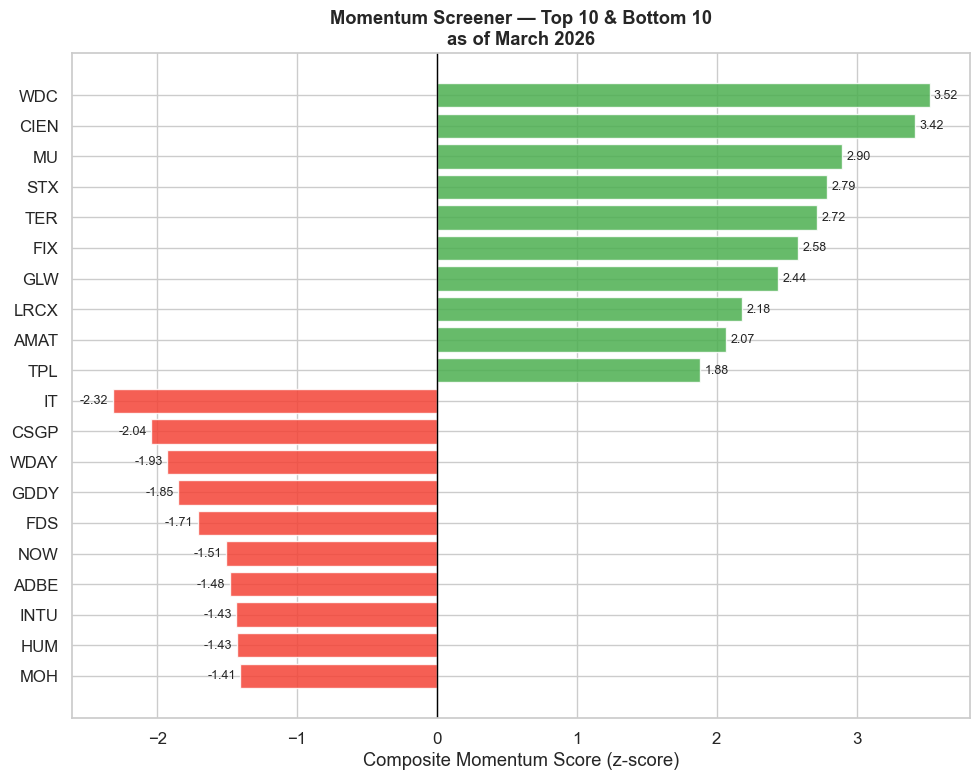

In [61]:
# ─────────────────────────────────────────────────────────────────────────────
# SCREENER CHART — HORIZONTAL BAR
# ─────────────────────────────────────────────────────────────────────────────
# Top 10 in green (above zero line), bottom 10 in red (below zero line).
# Sorted so the strongest long is at the top and weakest short at the bottom.

plot_df = pd.concat([top10, bottom10]).set_index("Ticker")["Composite"]

colours = ["#4CAF50" if v >= 0 else "#F44336" for v in plot_df.values]

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(plot_df.index, plot_df.values, color=colours, alpha=0.85)
ax.axvline(0, color="black", lw=1.0)

# Annotate each bar with its composite score
for bar, val in zip(bars, plot_df.values):
    offset = 0.03 if val >= 0 else -0.03
    ha     = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", ha=ha, fontsize=9)

ax.set_xlabel("Composite Momentum Score (z-score)")
ax.set_title(
    f"Momentum Screener — Top 10 & Bottom 10\n"
    f"as of {latest_month.strftime('%B %Y')}",
    fontweight="bold"
)
ax.invert_yaxis()    # highest score at top
plt.tight_layout()
plt.show()